# TropiCycloneNet — Startoff Notebook

This notebook supports you to start off with the **TropiCycloneNet Dataset (TCN_D)**.

It helps you:
1. download either the **test subset** or the **full dataset**
2. inspect the structure of **Data_1d, Data_3d, and Env-Data**
3. make **clean scientific tropical cyclone visualizations**
4. directions to work on with

---
## What this dataset is

TropiCycloneNet is a multimodal tropical cyclone dataset covering **1950–2023** across six major ocean basins. It contains:
- `Data_1d`: cyclone-center attributes such as longitude, latitude, pressure, wind
- `Data_3d`: gridded meteorological fields around the cyclone center
- `Env-Data`: structured environmental features

The official dataset page describes:
- full dataset: about **25.7 GB**
- test subset: about **3.34 GB**
- `Data_3d` covers a **20° × 20°** region centered on the storm
- spatial resolution: **0.25°**
- temporal resolution: **6-hourly**

## 0. Import packages

In [1]:
# CHANGED: UNCOMMENTED THE INSTALL LINE SO DEPENDENCIES ARE INSTALLED AUTOMATICALLY
!pip install -q gdown netCDF4 pandas numpy matplotlib cartopy seaborn xarray scipy

from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

DATA_DIR = Path("data/tropicyclonenet")
DATA_DIR.mkdir(parents=True, exist_ok=True)

## 1. Official download options
The official dataset repository provides:
- **Full dataset** (~25.7 GB)
- **Test subset** (~3.34 GB)

The GitHub documentation also provides a `read_TCND.py` script to visualize examples.

### recommendation
Start with the **test subset**. It is much more realistic for classroom work.

In [2]:
# Google Drive file IDs from the official dataset page
GDRIVE_IDS = {
    "full_dataset": "1BUAab0OYyiArbraQHu2oMoj_jF-nNUxT",
    "test_subset": "1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi",
}
GDRIVE_IDS

{'full_dataset': '1BUAab0OYyiArbraQHu2oMoj_jF-nNUxT',
 'test_subset': '1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi'}

Run the below cell to get the ready to copy command for download the dataset !

In [3]:
def gdown_command(file_id, output_name):
    return f"gdown --fuzzy 'https://drive.google.com/file/d/{file_id}/view?usp=sharing' -O {output_name}"

print("Test subset:")
print(gdown_command(GDRIVE_IDS["test_subset"], DATA_DIR / "TCND_test.zip"))
print("\nFull dataset:")
print(gdown_command(GDRIVE_IDS["full_dataset"], DATA_DIR / "TCND_full.zip"))

Test subset:
gdown --fuzzy 'https://drive.google.com/file/d/1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi/view?usp=sharing' -O data/tropicyclonenet/TCND_test.zip

Full dataset:
gdown --fuzzy 'https://drive.google.com/file/d/1BUAab0OYyiArbraQHu2oMoj_jF-nNUxT/view?usp=sharing' -O data/tropicyclonenet/TCND_full.zip


### CHANGED: ADDED ACTUAL DOWNLOAD CELLS BELOW (PREVIOUSLY THE NOTEBOOK ONLY PRINTED THE COMMANDS BUT NEVER EXECUTED THEM)

Run the cells below to download **both** the test subset and the full dataset. If you only want the test subset, skip the full dataset cell.

In [4]:
# CHANGED: ACTUALLY DOWNLOAD THE TEST SUBSET (~3.34 GB)
# (PREVIOUSLY THIS WAS ONLY SHOWN AS A COPY-PASTE COMMAND, NOT EXECUTED)
!gdown --fuzzy "https://drive.google.com/file/d/1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi/view?usp=sharing" -O data/tropicyclonenet/TCND_test.zip

Downloading...
From (original): https://drive.google.com/uc?id=1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi
From (redirected): https://drive.google.com/uc?id=1Xx2rzH6ztSGLTUR9EZkfDz5mQHsvhHsi&confirm=t&uuid=b7e26665-de88-45fe-b5ad-34cc9887a281
To: /Users/yasminakhmedova/Desktop/ICL/2 Semester/Climate Change/Group Project/data/tropicyclonenet/TCND_test.zip
  0%|                                               | 0.00/3.59G [00:00<?, ?B/s]

  0%|                                      | 4.19M/3.59G [00:00<01:39, 35.8MB/s]

  0%|                                      | 7.86M/3.59G [00:00<03:21, 17.8MB/s]

  0%|                                      | 10.5M/3.59G [00:00<03:46, 15.8MB/s]

  0%|▏                                     | 12.6M/3.59G [00:00<03:34, 16.6MB/s]

...

100%|█████████████████████████████████████▉| 3.58G/3.59G [01:37<00:00, 22.8MB/s]

100%|█████████████████████████████████████▉| 3.58G/3.59G [01:37<00:00, 22.1MB/s]

100%|█████████████████████████████████████▉| 3.58G/3.59G [01:38<00:00, 22.1MB/s]

100%|█████████████████████████████████████▉| 3.59G/3.59G [01:38<00:00, 24.1MB/s]

100%|██████████████████████████████████████| 3.59G/3.59G [01:38<00:00, 36.5MB/s]


In [5]:
# CHANGED: ACTUALLY DOWNLOAD THE FULL DATASET (~25.7 GB)
# SKIP THIS CELL IF YOU ONLY NEED THE TEST SUBSET
!gdown --fuzzy "https://drive.google.com/file/d/1BUAab0OYyiArbraQHu2oMoj_jF-nNUxT/view?usp=sharing" -O data/tropicyclonenet/TCND_full.zip

Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1BUAab0OYyiArbraQHu2oMoj_jF-nNUxT

but Gdown can't. Please check connections and permissions.


## 2. Inspect folder structure

After extraction, first inspect whether the archive contains:
- `Data_1d/`
- `Data_3d/`
- `Env-Data/`

That immediately tells students how multimodality is organized.

In [6]:
import zipfile

def unzip_file(zip_path, extract_dir=None):
    zip_path = Path(zip_path)
    if extract_dir is None:
        extract_dir = zip_path.with_suffix("")
    extract_dir = Path(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print(f"Extracted to {extract_dir}")
    return extract_dir

def print_tree(root, max_depth=2, prefix=""):
    root = Path(root)
    if not root.exists():
        print(f"Missing path: {root}")
        return
    for p in sorted(root.iterdir()):
        print(prefix + p.name + ("/" if p.is_dir() else ""))
        if p.is_dir() and max_depth > 0:
            print_tree(p, max_depth=max_depth-1, prefix=prefix + "    ")

# CHANGED: UNCOMMENTED THE UNZIP AND PRINT_TREE CALLS (WERE PREVIOUSLY COMMENTED OUT)
unzip_file(DATA_DIR / "TCND_test.zip", DATA_DIR / "TCND_test")
print_tree(DATA_DIR / "TCND_test", max_depth=2)

Extracted to data/tropicyclonenet/TCND_test
.DS_Store
TCND_test/
    .DS_Store
    Data1D/
        .DS_Store
        EP/
        NA/
        NI/
        SI/
        SP/
        WP/
    Data3D/
        .DS_Store
        EP/
        NA/
        NI/
        SI/
        SP/
        WP/
    Env-Data/
        .DS_Store
        EP/
        NA/
        NI/
        SI/
        SP/
        WP/


In [7]:
# CHANGED: ADDED UNZIP FOR THE FULL DATASET
# SKIP THIS CELL IF YOU ONLY DOWNLOADED THE TEST SUBSET
unzip_file(DATA_DIR / "TCND_full.zip", DATA_DIR / "TCND_full")
print_tree(DATA_DIR / "TCND_full", max_depth=2)

FileNotFoundError: [Errno 2] No such file or directory: 'data/tropicyclonenet/TCND_full.zip'

In [8]:
def scan_files(root):
    root = Path(root)
    rows = []
    for p in root.rglob("*"):
        if p.is_file():
            rows.append({
                "path": str(p),
                "suffix": p.suffix.lower(),
                "size_mb": round(p.stat().st_size / 1024**2, 3)
            })
    return pd.DataFrame(rows).sort_values(["suffix", "path"]).reset_index(drop=True)

# CHANGED: UNCOMMENTED THE SCAN_FILES CALL (WAS PREVIOUSLY COMMENTED OUT)
files_df = scan_files(DATA_DIR / "TCND_test")
files_df.head(100)

,path,suffix,size_mb
0,data/tropicyclonenet/TCND_test/.DS_Store,,0.006
1,data/tropicyclonenet/TCND_test/TCND_test/.DS_S...,,0.006
2,data/tropicyclonenet/TCND_test/TCND_test/Data1...,,0.006
3,data/tropicyclonenet/TCND_test/TCND_test/Data1...,,0.006
4,data/tropicyclonenet/TCND_test/TCND_test/Data3...,,0.006
...,...,...,...
95,data/tropicyclonenet/TCND_test/TCND_test/Data3...,.nc,0.335
96,data/tropicyclonenet/TCND_test/TCND_test/Data3...,.nc,0.335
97,data/tropicyclonenet/TCND_test/TCND_test/Data3...,.nc,0.335
98,data/tropicyclonenet/TCND_test/TCND_test/Data3...,.nc,0.335


## 3. Reading patterns

The official docs suggest using `read_TCND.py` with:
`python read_TCND.py dataset_path TC_name TC_date area train_val_test`

For simple loading as startoff, it is useful to add a more explicit inspection workflow:
- identify tabular files in `Data_1d`
- identify gridded files in `Data_3d`
- inspect environmental feature files in `Env-Data`

In [9]:
def preview_tabular(path, n=5):
    path = Path(path)
    if path.suffix.lower() == ".csv":
        return pd.read_csv(path, nrows=n)
    elif path.suffix.lower() in [".txt"]:
        return pd.read_csv(path, sep=None, engine="python", nrows=n)
    elif path.suffix.lower() in [".parquet"]:
        return pd.read_parquet(path).head(n)
    else:
        raise ValueError(f"Unsupported tabular preview: {path.suffix}")

In [10]:
def guess_tc_columns(df):
    rename = {}
    for c in df.columns:
        low = c.lower()
        if low in ["lat", "latitude"]:
            rename[c] = "latitude"
        elif low in ["lon", "longitude", "long"]:
            rename[c] = "longitude"
        elif "wind" in low:
            rename[c] = "wind"
        elif "press" in low:
            rename[c] = "pressure"
        elif "time" in low or "date" in low:
            rename[c] = "time"
        elif "name" in low:
            rename[c] = "tc_name"
    return df.rename(columns=rename)

## 4. Scientific visualization helpers

These are tailored to cyclone data:
- track maps
- intensity-time plots
- basin summaries
- storm-centered field plots

In [11]:
def plot_track(df, title="Tropical cyclone track", basin=None):
    df = guess_tc_columns(df.copy())
    if basin is not None and "basin" in df.columns:
        df = df[df["basin"] == basin]
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        df = df.sort_values("time")

    if HAS_CARTOPY:
        fig = plt.figure(figsize=(10,5))
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4)
        ax.plot(df["longitude"], df["latitude"], "-o", ms=3, transform=ccrs.PlateCarree())
        ax.set_title(title, weight="bold")
    else:
        fig, ax = plt.subplots(figsize=(10,5))
        ax.plot(df["longitude"], df["latitude"], "-o", ms=3)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.set_title(title, weight="bold")
        ax.grid(alpha=0.3)
    plt.tight_layout()
    return fig

def plot_intensity_time(df, wind_col="wind", pressure_col="pressure"):
    df = guess_tc_columns(df.copy())
    if "time" in df.columns:
        df["time"] = pd.to_datetime(df["time"], errors="coerce")
        df = df.sort_values("time")

    fig, ax1 = plt.subplots(figsize=(11,4))
    if wind_col in df.columns:
        ax1.plot(df["time"], df[wind_col], label="Wind")
        ax1.set_ylabel("Wind")
    if pressure_col in df.columns:
        ax2 = ax1.twinx()
        ax2.plot(df["time"], df[pressure_col], "--", label="Pressure")
        ax2.set_ylabel("Pressure")
    ax1.set_title("Storm intensity evolution", weight="bold")
    ax1.grid(alpha=0.3)
    plt.tight_layout()
    return fig

def plot_basin_counts(df, basin_col="basin"):
    fig, ax = plt.subplots(figsize=(7,4))
    df[basin_col].value_counts().sort_values(ascending=False).plot.bar(ax=ax)
    ax.set_title("Cyclone counts by basin", weight="bold")
    ax.set_ylabel("Count")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    return fig

## 5. Example storm-centered grid visualization

The official description says `Data_3d` includes:
- geopotential height (you can learn more about geopotential height [here](https://www.weather.gov/source/zhu/ZHU_Training_Page/Miscellaneous/Heights_Thicknesses/thickness_temperature.htm#GEOPOTENTIAL))
- U and V wind components
- pressure levels 200, 500, 850, 925 hPa 
- SST

If your `Data_3d` files are NetCDF-like, the template below is a good starting point.

Dataset Variables:
 ['u', 'v', 'z', 'sst']
Coordinates:
 ['time', 'pressure_level', 'latitude', 'longitude']


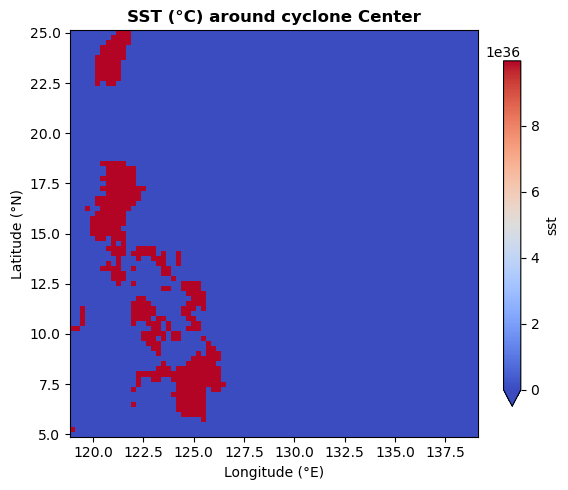

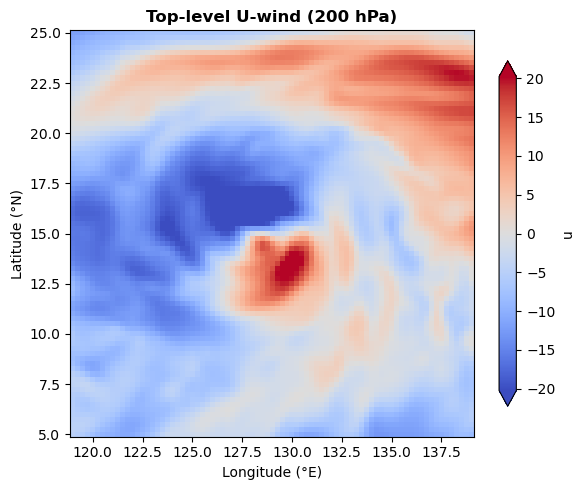

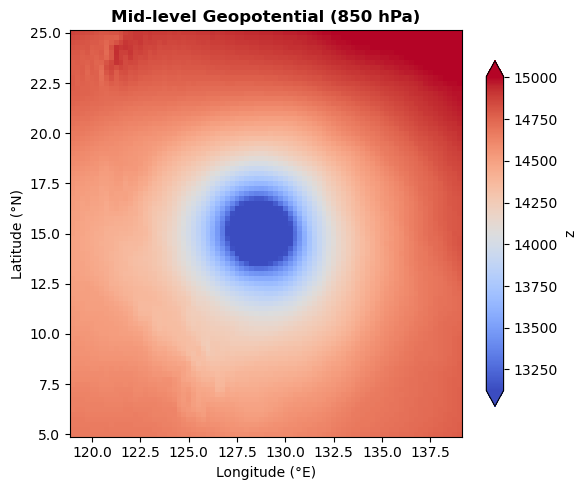

In [12]:
try:
    import xarray as xr
except Exception:
    xr = None

def plot_storm_field(da, title=None, cmap="coolwarm", figsize=(6,5)):
    fig, ax = plt.subplots(figsize=figsize)
    da.plot(ax=ax, cmap=cmap, robust=True, cbar_kwargs={"shrink":0.85})
    ax.set_title(title or str(da.name), weight="bold")
    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")
    plt.tight_layout()
    return fig

# Let's inspect an actual file as an example
nc_file = "data/tropicyclonenet/TCND_test/TCND_test/Data3D/WP/2018/MANGKHUT/TCND_MANGKHUT_2018091312_sst_z_u_v.nc"
if xr is not None and Path(nc_file).exists():
    ds3d = xr.open_dataset(nc_file)
    print("Dataset Variables:\n", list(ds3d.data_vars))
    print("Coordinates:\n", list(ds3d.coords))
    
    # 1) SST has only spatial dimensions (latitude, longitude) and no 'time'
    fig_sst = plot_storm_field(ds3d["sst"], "SST (°C) around cyclone Center")
    
    # 2) U, V, Z have dimensions (time, pressure_level, latitude, longitude)
    # Select the first time slice, and pressure_level=0 (e.g. 200 hPa level)
    fig_u = plot_storm_field(ds3d["u"].isel(time=0, pressure_level=0), "Top-level U-wind (200 hPa)")
    
    # Select pressure_level=2 (e.g. 850 hPa level)
    fig_z = plot_storm_field(ds3d["z"].isel(time=0, pressure_level=2), "Mid-level Geopotential (850 hPa)")


## 6. Suggested project directions

### A — Track forecasting vs intensity forecasting
One may argue whether the same input modalities help both tasks equally, or whether track and intensity need different information.

### B — Basin generalization
Train on one basin or a subset of basins, then test transfer to another basin:
- Atlantic → Western Pacific
- Western Pacific → Indian Ocean

### C — Environmental precursors of rapid intensification
Use `Env-Data` and `Data_3d` to study which and how environmental conditions precede sharp increases in wind speed. You can even predict the next state, intensity growth or the timing of the next sharp increase.

### D — Multimodal fusion ablation
Compare:
- `Data_1d` only
- `Data_3d` only
- `Env-Data` only
- fused models

## 7. extra notes / comments

TropiCycloneNet is scientifically engaging, especially for the interest in hazards and extremes.

It works very well if you want **extreme-event, multimodal, time series, and spatiotemporal** projects.

## 8. Generate and Display GIF Animation

The following code creates a GIF animation across time steps for the MANGKHUT cyclone using the `Data_3d` NetCDF files, similar to the tracking animations seen on the project's repository. We will compute the wind speed at 850 hPa (mid-level) from the `u` and `v` components and plot it frame-by-frame.

In [13]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, Image, HTML

def create_tc_animation(data_dir, output_gif="tc_animation.gif", fps=10):
    nc_files = sorted(glob.glob(f"{data_dir}/*.nc"))
    if not nc_files:
        print(f"No .nc files found in {data_dir}")
        return None
    
    print(f"Found {len(nc_files)} files. Generating animation...")
    fig, ax = plt.subplots(figsize=(6, 5))
    
    # Initialize first frame
    ds = xr.open_dataset(nc_files[0])
    # Try calculating wind speed at 850 hPa (index 2 for pressure_level)
    u_val = ds["u"].isel(time=0, pressure_level=2).values
    v_val = ds["v"].isel(time=0, pressure_level=2).values
    wind_spd = np.sqrt(u_val**2 + v_val**2)

    img = ax.imshow(wind_spd, cmap="viridis", origin="lower")
    plt.colorbar(img, ax=ax, label="Wind speed (m/s)")
    ax.set_xlabel("Longitude index")
    ax.set_ylabel("Latitude index")

    # Adding text for the timestamp
    title_text = ax.set_title("", weight="bold")
    
    def animate(i):
        ds_frame = xr.open_dataset(nc_files[i])
        u_f = ds_frame["u"].isel(time=0, pressure_level=2).values
        v_f = ds_frame["v"].isel(time=0, pressure_level=2).values
        wind_spd_f = np.sqrt(u_f**2 + v_f**2)
        img.set_array(wind_spd_f)
        
        # Extract Datetime from filename
        fname = os.path.basename(nc_files[i])
        date_str = fname.split('_')[2] # E.g., 2018091312
        title_text.set_text(f"Wind Speed (850 hPa) - {date_str[:8]} {date_str[8:]}:00")
        
        ds_frame.close()
        return [img, title_text]
    
    anim = animation.FuncAnimation(fig, animate, frames=len(nc_files), interval=1000/fps, blit=True)
    anim.save(output_gif, writer="pillow", fps=fps)
    plt.close(fig) # Prevent duplicate static plot in output
    print(f"Saved {output_gif}")
    
    return output_gif

# Directory for MANGKHUT
mangkhut_dir = "data/tropicyclonenet/TCND_test/TCND_test/Data3D/WP/2018/MANGKHUT"
gif_path = create_tc_animation(mangkhut_dir, "mangkhut_anim.gif", fps=8)

if gif_path:
    # Display the GIF inside the notebook
    display(HTML(f'<img src="{gif_path}" style="width:600px; height:auto;" />'))

Found 43 files. Generating animation...


Saved mangkhut_anim.gif


## 9. Tracking the Cyclone over a Map

While generating an animation frame by frame is nice, tracing the track on a geographical map is much more insightful, similar to how true satellite tracking looks. We can use `Cartopy` to plot the coastlines and overlay the wind speed patch at the exact location along with its path!

In [14]:
import os
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, HTML

# Only run if Cartopy is available
if HAS_CARTOPY:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    def create_mapped_tc_animation(data_dir, output_gif="tc_mapped_animation.gif", fps=7):
        nc_files = sorted(glob.glob(f"{data_dir}/*.nc"))
        if not nc_files: return None
        
        # 1. Compute bounds
        lons, lats, tc_lons, tc_lats = [], [], [], []
        for f in nc_files:
            with xr.open_dataset(f) as ds:
                lons.extend([ds['longitude'].min().values, ds['longitude'].max().values])
                lats.extend([ds['latitude'].min().values, ds['latitude'].max().values])
                
                # Center index is the storm's exact location
                tc_lon = ds['longitude'][len(ds['longitude']) // 2].values
                tc_lat = ds['latitude'][len(ds['latitude']) // 2].values
                tc_lons.append(tc_lon)
                tc_lats.append(tc_lat)

        extent = [min(lons)-2, max(lons)+2, min(lats)-2, max(lats)+2]
        
        # 2. Setup Aesthetic Base Plot
        plt.style.use('dark_background') # Give it a sleek dark theme
        fig = plt.figure(figsize=(10, 6), dpi=120)
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.set_extent(extent, crs=ccrs.PlateCarree())
        
        # Apply strict professional aesthetic background
        ax.set_facecolor('#112233') # Ocean
        land_feature = cfeature.NaturalEarthFeature(category='physical', name='land', scale='50m', facecolor='#223344')
        ax.add_feature(land_feature, zorder=1)
        ax.coastlines(linewidth=0.8, color='#556677', zorder=2)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor='#556677', zorder=2)
        
        # Semi-transparent gridlines
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.3, color='white', linestyle='--', zorder=3)
        gl.top_labels = False
        gl.right_labels = False
        gl.xlabel_style = {'color': 'lightgray', 'size': 9}
        gl.ylabel_style = {'color': 'lightgray', 'size': 9}
        
        # Title box
        title_text = ax.text(0.02, 0.95, "", transform=ax.transAxes, color='white', 
                             fontsize=12, weight='bold', bbox=dict(facecolor='black', alpha=0.6, edgecolor='none'), zorder=10)
        
        # Dynamic track line with glowing scatter
        track_line, = ax.plot([], [], '-', color='cyan', linewidth=2, alpha=0.8, transform=ccrs.PlateCarree(), zorder=5)
        track_points = ax.scatter([], [], s=30, color='white', edgecolors='cyan', zorder=6, transform=ccrs.PlateCarree())
        current_point = ax.scatter([], [], s=80, color='red', edgecolors='white', zorder=7, transform=ccrs.PlateCarree())
        
        # Set up a dummy pcolormesh specifically to generate ONE neat horizontal colorbar
        dummy_z = np.zeros((2, 2))
        dummy_lons = np.array([[extent[0], extent[1]], [extent[0], extent[1]]])
        dummy_lats = np.array([[extent[2], extent[2]], [extent[3], extent[3]]])
        dummy_mesh = ax.pcolormesh(dummy_lons, dummy_lats, dummy_z, cmap="magma", 
                                   vmin=0, vmax=50, transform=ccrs.PlateCarree(), visible=False, zorder=0)
        
        # Add a sleek, small horizontal colorbar at the bottom right
        cax = fig.add_axes([0.65, 0.15, 0.22, 0.02]) # [left, bottom, width, height]
        cbar = plt.colorbar(dummy_mesh, cax=cax, orientation='horizontal')
        cbar.set_label("Wind Speed (m/s)", color='white', size=10, weight='bold')
        cbar.ax.tick_params(colors='white', labelsize=9)
        cbar.outline.set_edgecolor('#556677')
        
        pmesh = [None]
        
        def animate(i):
            if pmesh[0] is not None:
                pmesh[0].remove()
                
            with xr.open_dataset(nc_files[i]) as ds_frame:
                u_f = ds_frame["u"].isel(time=0, pressure_level=2).values
                v_f = ds_frame["v"].isel(time=0, pressure_level=2).values
                w_spd_f = np.sqrt(u_f**2 + v_f**2)

                lon_f, lat_f = ds_frame['longitude'].values, ds_frame['latitude'].values
                lon_f_2d, lat_f_2d = np.meshgrid(lon_f, lat_f)
                
                # Plot the cyclone wind mesh using Magma glow
                pmesh[0] = ax.pcolormesh(lon_f_2d, lat_f_2d, w_spd_f, cmap="magma", 
                                         vmin=0, vmax=50, transform=ccrs.PlateCarree(), alpha=0.85, shading='gouraud', zorder=4)
                
                # Update tracing locations
                track_line.set_data(tc_lons[:i+1], tc_lats[:i+1])
                track_points.set_offsets(np.column_stack((tc_lons[:i+1], tc_lats[:i+1])))
                current_point.set_offsets(np.column_stack(([tc_lons[i]], [tc_lats[i]])))
                
                # Update timestamp overlay
                fname = os.path.basename(nc_files[i])
                date_str = fname.split('_')[2]
                time_formatted = f"{date_str[:4]}-{date_str[4:6]}-{date_str[6:8]} {date_str[8:]}:00 UTC"
                title_text.set_text(f"TC MANGKHUT (850hPa) | {time_formatted}")
                
            return [pmesh[0], track_line, track_points, current_point, title_text]
            
        anim = animation.FuncAnimation(fig, animate, frames=len(nc_files), interval=1000/fps, blit=False)
        anim.save(output_gif, writer="pillow", fps=fps)
        
        # Reset the Matplotlib plot style so it doesn't affect subsequent notebook plots globally
        plt.style.use('default')
        plt.close(fig)
        return output_gif

    mangkhut_dir = "data/tropicyclonenet/TCND_test/TCND_test/Data3D/WP/2018/MANGKHUT"
    print("Generating aesthetic geographic track animation...")
    mapped_gif = create_mapped_tc_animation(mangkhut_dir, "mangkhut_mapped_anim.gif", fps=7)
    
    if mapped_gif:
        display(HTML(f'<img src="{mapped_gif}?{np.random.randint(1000)}" style="width:800px; height:auto; box-shadow: 0 4px 8px 0 rgba(0,0,0,0.5); border-radius: 5px;" />'))
else:
    print("Cartopy is not installed. Please install it to run this visualization.")


Generating aesthetic geographic track animation...


---

## 10. Data Statistics: Basin Generalization (WP -> SP)

The remaining sections focus on the basin generalization task: training a tropical cyclone model on the Western North Pacific (WP) and evaluating zero-shot transfer to the South Pacific (SP). This is motivated by a fundamental asymmetry in the dataset: WP is data-rich while SP is data-scarce, making it impractical to train a reliable model on SP alone.

Four analyses are presented:
1. **Sample size imbalance** across all six basins, quantifying the data scarcity problem
2. **Storm track geography**, showing the spatial separation between training and test domains
3. **24-hour direction label distributions**, revealing the hemisphere-driven distributional shift that any transfer approach must handle
4. **Vertical wind shear distributions**, testing whether the underlying atmospheric physics is similar enough across basins for transfer to succeed

### 10a. Sample Size Imbalance Across Basins

The number of storms and individual time steps (6-hourly observations) are counted per basin in the test subset. Each time step corresponds to one Data1D record, one Data3D NetCDF file, and one Env-Data `.npy` file, so these counts apply across all three data modalities.

Basin  Storms  Time steps
   WP     131        4562
   NA     101        3895
   EP      93        3342
   SI      81        2839
   SP      30         922
   NI      20         527


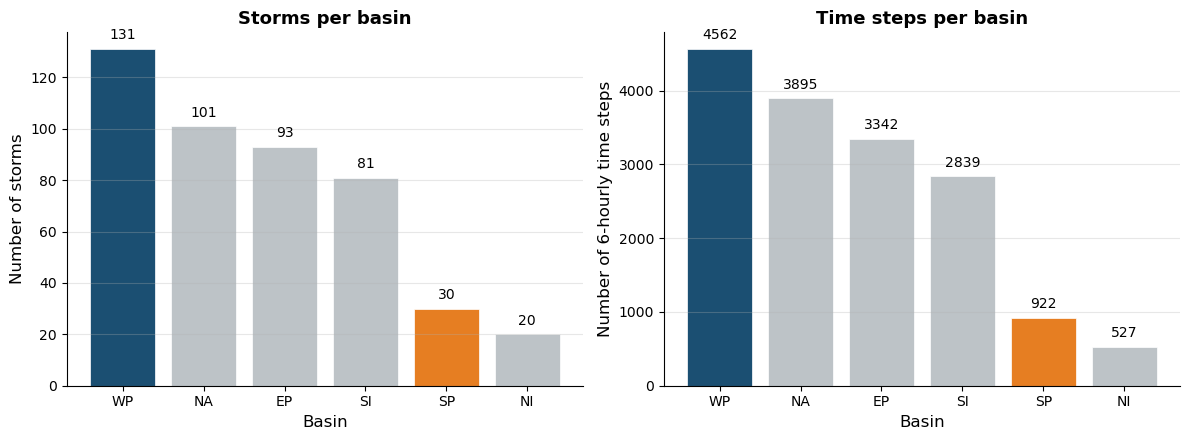

Saved basin_imbalance.png


In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

TCND_ROOT = Path("data/tropicyclonenet/TCND_test/TCND_test")
BASINS = ["WP", "EP", "NA", "NI", "SI", "SP"]

# count storms and time steps per basin from Env-Data (one .npy per time step)
basin_storms, basin_steps = {}, {}
for basin in BASINS:
    env_root = TCND_ROOT / "Env-Data" / basin
    npy_files = list(env_root.rglob("*.npy"))
    storms = set(f.parent.name for f in npy_files)
    basin_storms[basin] = len(storms)
    basin_steps[basin] = len(npy_files)

# build summary table
summary = pd.DataFrame({
    "Basin": BASINS,
    "Storms": [basin_storms[b] for b in BASINS],
    "Time steps": [basin_steps[b] for b in BASINS],
})
summary = summary.sort_values("Time steps", ascending=False).reset_index(drop=True)
print(summary.to_string(index=False))

# bar chart
WP_COLOR = "#1b4f72"
SP_COLOR = "#e67e22"
OTHER_COLOR = "#bdc3c7"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, col, ylabel in [(ax1, "Storms", "Number of storms"), (ax2, "Time steps", "Number of 6-hourly time steps")]:
    colors = [WP_COLOR if b == "WP" else SP_COLOR if b == "SP" else OTHER_COLOR
              for b in summary["Basin"]]
    bars = ax.bar(summary["Basin"], summary[col], color=colors, edgecolor="white", linewidth=0.5)
    ax.set_ylabel(ylabel, fontsize=12)
    ax.set_xlabel("Basin", fontsize=12)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.3)

    # annotate each bar
    for bar, val in zip(bars, summary[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(summary[col]) * 0.02,
                str(val), ha="center", va="bottom", fontsize=10)

ax1.set_title("Storms per basin", fontsize=13, fontweight="bold")
ax2.set_title("Time steps per basin", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig("basin_imbalance.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved basin_imbalance.png")

WP contains 131 storms and 4,562 time steps. SP contains 30 storms and 922 time steps, roughly 5x fewer in both counts. This imbalance is the primary motivation for transfer learning: SP alone does not provide enough data to train a deep learning model from scratch, but WP does. If a model trained on WP can generalise to SP, the data scarcity problem is effectively solved.

The remaining four basins (EP, NA, SI, NI) sit between these extremes. NI is the smallest overall (20 storms, 527 steps), which would make it another candidate for transfer, but WP -> SP is the more scientifically interesting pair because the hemisphere flip introduces a structural distributional shift beyond just sample size.

### 10b. Storm Track Map: WP vs SP

All storm tracks from both basins are plotted on a single Pacific-centred map. The Data1D files contain normalised longitude and latitude at each 6-hourly time step. The correct denormalisation was determined empirically by cross-referencing Data1D values against the `location` field in Env-Data (which stores coordinates in 0.1-degree units):
- Longitude (degrees E): `LONG x 5 + 180`
- Latitude (degrees N): `LAT x 5`

Note: the dataset documentation lists different normalisation formulas (`LONG / 3600`, `(LAT + 900) / 1800`), but these do not match the actual Data1D values in the test subset.

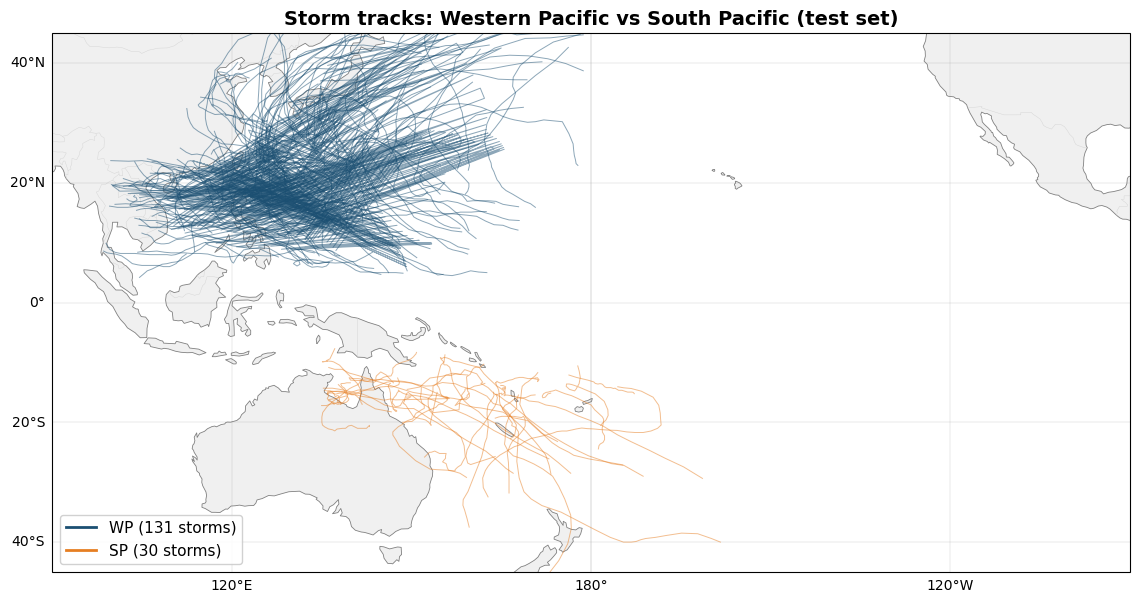

Saved track_map.png


In [16]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.lines import Line2D

COL_NAMES = ["ID", "BASIN_ID", "LONG", "LAT", "PRES", "WND", "DATETIME", "Name"]

# load Data1D for WP and SP
all_1d = []
for basin in ["WP", "SP"]:
    txt_dir = TCND_ROOT / "Data1D" / basin / "test"
    for fp in sorted(txt_dir.glob("*.txt")):
        df = pd.read_csv(fp, sep="\t", header=None, names=COL_NAMES)
        df["basin"] = basin
        all_1d.append(df)

df_1d = pd.concat(all_1d, ignore_index=True)

# denormalise coordinates (empirically verified against Env-Data location field)
df_1d["lon_deg"] = df_1d["LONG"] * 5 + 180
df_1d["lat_deg"] = df_1d["LAT"] * 5

wp_1d = df_1d[df_1d["basin"] == "WP"]
sp_1d = df_1d[df_1d["basin"] == "SP"]

# plot
fig = plt.figure(figsize=(14, 7))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=180))
ax.set_extent([90, 270, -45, 45], crs=ccrs.PlateCarree())
ax.coastlines(linewidth=0.6, color="grey")
ax.add_feature(cfeature.LAND, facecolor="#f0f0f0", zorder=0)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, edgecolor="lightgrey")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.4, color="grey")
gl.top_labels = False
gl.right_labels = False

for name, grp in wp_1d.groupby("Name"):
    grp = grp.sort_values("ID")
    ax.plot(grp["lon_deg"], grp["lat_deg"], lw=0.7, alpha=0.5,
            color=WP_COLOR, transform=ccrs.PlateCarree())

for name, grp in sp_1d.groupby("Name"):
    grp = grp.sort_values("ID")
    ax.plot(grp["lon_deg"], grp["lat_deg"], lw=0.7, alpha=0.5,
            color=SP_COLOR, transform=ccrs.PlateCarree())

handles = [
    Line2D([0], [0], color=WP_COLOR, lw=2, label=f"WP ({wp_1d['Name'].nunique()} storms)"),
    Line2D([0], [0], color=SP_COLOR, lw=2, label=f"SP ({sp_1d['Name'].nunique()} storms)"),
]
ax.legend(handles=handles, loc="lower left", fontsize=11, framealpha=0.9)
ax.set_title("Storm tracks: Western Pacific vs South Pacific (test set)",
             fontsize=14, fontweight="bold")

plt.savefig("track_map.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved track_map.png")

The two basins occupy entirely separate geographic regions with no spatial overlap. WP storms form in the tropical western Pacific and generally track northwestward toward East Asia. SP storms form in the tropical South Pacific and generally track westward or southwestward, with many recurving southeastward toward higher latitudes.

This geographic separation has two consequences for transfer learning. First, any model with access to absolute longitude or latitude features can trivially distinguish the two basins without learning any cyclone physics, so these features must be masked or replaced. Second, the Coriolis effect reverses across the equator: Northern Hemisphere storms drift poleward (northward), while Southern Hemisphere storms drift poleward (southward). A naive model trained on WP track directions will systematically mispredict SP tracks unless it accounts for this hemisphere flip.

### 10c. 24-Hour Direction Label Distribution: WP vs SP

The `future_direction24` label in Env-Data encodes the direction of storm movement over the next 24 hours as an integer 0-7, mapped to 8 compass directions starting at East and proceeding clockwise: E, SE, S, SW, W, NW, N, NE. This mapping was verified empirically by comparing the labels against the actual 24-hour displacement computed from Data1D coordinates (13,000+ samples, 92-100% agreement per class). A value of -1 indicates missing data (the last few time steps of each storm, where the storm dissipates before 24 hours have elapsed); these are excluded.

A polar plot is used instead of a bar chart to show direction on its natural circular axis. If the hemisphere flip is a dominant factor, WP and SP should show distinct directional preferences.

Valid samples - WP: 3982, SP: 802


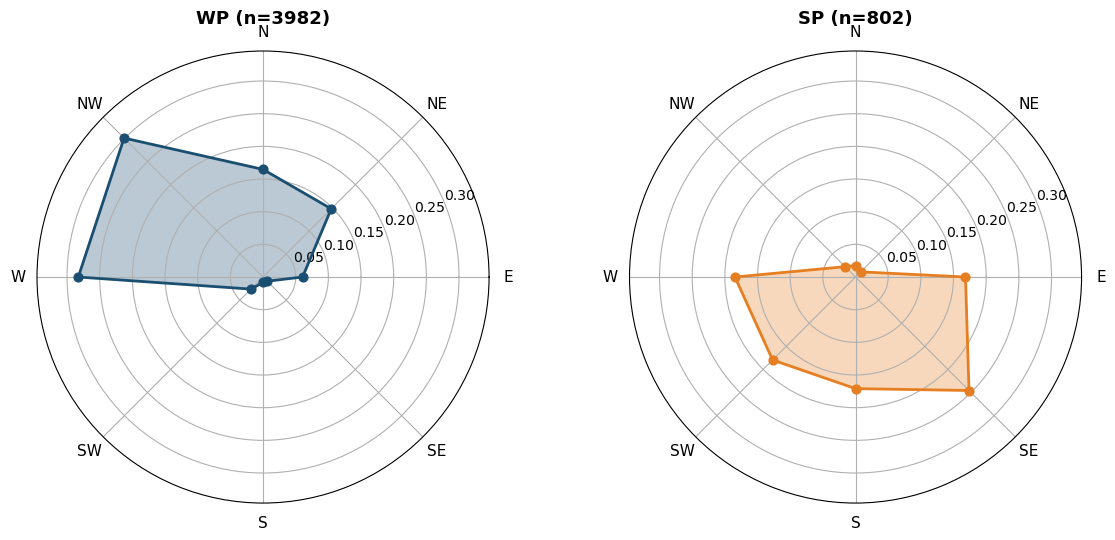

Saved direction_distribution.png
  WP top 3: NW (30.1%), W (28.3%), N (16.5%)
  SP top 3: SE (24.6%), W (18.5%), SW (18.0%)


In [17]:
# empirically verified mapping: label 0=E, 1=SE, 2=S, 3=SW, 4=W, 5=NW, 6=N, 7=NE
DIR_LABELS = ["E", "SE", "S", "SW", "W", "NW", "N", "NE"]

def load_env_directions(basin):
    """Load future_direction24 for all samples, excluding -1 sentinels."""
    dirs = []
    env_root = TCND_ROOT / "Env-Data" / basin
    for npy_path in sorted(env_root.rglob("*.npy")):
        d = np.load(npy_path, allow_pickle=True).item()
        val = int(d["future_direction24"])
        if val >= 0:
            dirs.append(val)
    return np.array(dirs)

wp_dirs = load_env_directions("WP")
sp_dirs = load_env_directions("SP")
print(f"Valid samples - WP: {len(wp_dirs)}, SP: {len(sp_dirs)}")

# compute proportions
wp_prop = np.bincount(wp_dirs, minlength=8) / len(wp_dirs)
sp_prop = np.bincount(sp_dirs, minlength=8) / len(sp_dirs)

# polar plot
# math-convention angles for plotting: E=0, SE=315, S=270, SW=225, W=180, NW=135, N=90, NE=45
compass_angles_deg = [0, 315, 270, 225, 180, 135, 90, 45]
angles = np.deg2rad(compass_angles_deg)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), subplot_kw=dict(projection="polar"))

for ax, prop, color, title in [
    (ax1, wp_prop, WP_COLOR, f"WP (n={len(wp_dirs)})"),
    (ax2, sp_prop, SP_COLOR, f"SP (n={len(sp_dirs)})"),
]:
    # close the polygon
    angles_closed = np.append(angles, angles[0])
    prop_closed = np.append(prop, prop[0])

    ax.fill(angles_closed, prop_closed, alpha=0.3, color=color)
    ax.plot(angles_closed, prop_closed, color=color, linewidth=2)
    ax.scatter(angles, prop, color=color, s=40, zorder=5)

    # set compass labels
    ax.set_theta_zero_location("E")  # 0 degrees = East
    ax.set_theta_direction(1)        # counterclockwise
    ax.set_thetagrids(compass_angles_deg, DIR_LABELS, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=20)
    ax.set_ylim(0, max(wp_prop.max(), sp_prop.max()) * 1.15)

plt.tight_layout()
plt.savefig("direction_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved direction_distribution.png")

# print top directions
for label, prop, name in [("WP", wp_prop, "WP"), ("SP", sp_prop, "SP")]:
    ranked = sorted(zip(DIR_LABELS, prop), key=lambda x: -x[1])
    top3 = ", ".join(f"{d} ({p:.1%})" for d, p in ranked[:3])
    print(f"  {name} top 3: {top3}")

The distributions are clearly distinct. WP storms move predominantly toward the NW (30.1%) and W (28.3%), with a secondary N component (16.5%), consistent with the well-known northwestward tracking of Western Pacific typhoons toward East Asia, followed by poleward recurvature. SP storms are more spread out: the most common direction is SE (24.6%), followed by W (18.5%) and SW (18.0%). In the Southern Hemisphere, SE corresponds to poleward (southward) recurvature with an eastward component, the mirror image of the NE recurvature commonly observed in WP.

This distributional shift is the clearest evidence that naive zero-shot transfer will fail for direction prediction. A model trained on WP will learn that storms predominantly head NW/W. Applied to SP, it will assign high probability to NW/W when the correct answer is more often SE/W/SW. Any successful transfer approach must either (a) explicitly remap direction labels when crossing hemispheres, or (b) represent direction relative to the pole rather than in absolute compass terms.

### 10d. Vertical Wind Shear: WP vs SP

Vertical wind shear (the magnitude of the vector wind difference between 200 hPa and 850 hPa) is one of the most physically important predictors of tropical cyclone intensity. High shear disrupts the warm-core structure and inhibits intensification; low shear allows storms to strengthen. Unlike longitude or latitude, shear is a basin-agnostic atmospheric quantity that should behave similarly in any ocean basin.

The shear is computed from the Data3D `u` and `v` wind components. Following standard practice, the wind vectors are area-averaged over the inner 5-degree box (the central 21x21 pixels of the 81x81 grid, corresponding to ~5 degrees at 0.25-degree resolution) before computing the vector difference. A random subsample of 500 time steps per basin is used to keep computation time reasonable.

Available files - WP: 4562, SP: 922


Computed shear - WP: 500 samples, SP: 500 samples


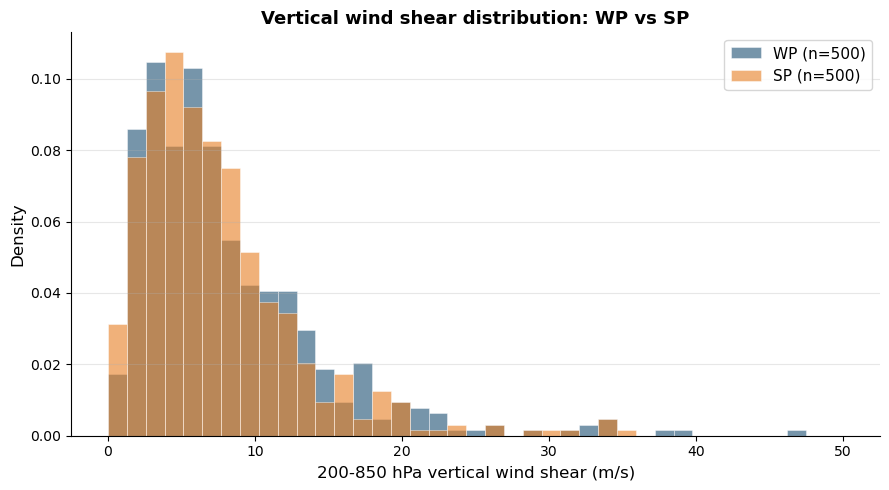

Saved shear_distribution.png
  WP: mean=8.2 m/s, median=6.4 m/s, std=6.7 m/s, range=[0.5, 53.9]
  SP: mean=7.4 m/s, median=6.2 m/s, std=5.5 m/s, range=[0.3, 35.1]


In [18]:
import xarray as xr

def compute_shear(nc_path):
    """Compute 200-850 hPa vertical wind shear, area-averaged over the inner 5 degrees."""
    ds = xr.open_dataset(nc_path)
    # pressure_level indices: 0=200, 1=500, 2=850, 3=925
    # inner 5-degree box = central 21x21 of the 81x81 grid (indices 30:51)
    u200 = ds["u"].isel(time=0, pressure_level=0).values[30:51, 30:51]
    u850 = ds["u"].isel(time=0, pressure_level=2).values[30:51, 30:51]
    v200 = ds["v"].isel(time=0, pressure_level=0).values[30:51, 30:51]
    v850 = ds["v"].isel(time=0, pressure_level=2).values[30:51, 30:51]
    ds.close()

    du = (u200 - u850).mean()
    dv = (v200 - v850).mean()
    return np.sqrt(du**2 + dv**2)

# collect all NetCDF paths per basin
wp_nc = sorted((TCND_ROOT / "Data3D" / "WP").rglob("*.nc"))
sp_nc = sorted((TCND_ROOT / "Data3D" / "SP").rglob("*.nc"))
print(f"Available files - WP: {len(wp_nc)}, SP: {len(sp_nc)}")

# subsample for speed
rng = np.random.default_rng(42)
n_sample = 500
wp_sample = rng.choice(wp_nc, size=min(n_sample, len(wp_nc)), replace=False)
sp_sample = rng.choice(sp_nc, size=min(n_sample, len(sp_nc)), replace=False)

wp_shear = np.array([compute_shear(f) for f in wp_sample])
sp_shear = np.array([compute_shear(f) for f in sp_sample])
print(f"Computed shear - WP: {len(wp_shear)} samples, SP: {len(sp_shear)} samples")

# histogram
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 50, 40)

ax.hist(wp_shear, bins=bins, alpha=0.6, color=WP_COLOR, edgecolor="white",
        linewidth=0.5, label=f"WP (n={len(wp_shear)})", density=True)
ax.hist(sp_shear, bins=bins, alpha=0.6, color=SP_COLOR, edgecolor="white",
        linewidth=0.5, label=f"SP (n={len(sp_shear)})", density=True)

ax.set_xlabel("200-850 hPa vertical wind shear (m/s)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Vertical wind shear distribution: WP vs SP", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("shear_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved shear_distribution.png")

# summary stats
for name, shear in [("WP", wp_shear), ("SP", sp_shear)]:
    print(f"  {name}: mean={shear.mean():.1f} m/s, median={np.median(shear):.1f} m/s, "
          f"std={shear.std():.1f} m/s, range=[{shear.min():.1f}, {shear.max():.1f}]")

The shear distributions overlap substantially. WP has a mean shear of 8.2 m/s (median 6.4, std 6.7); SP has a mean of 7.4 m/s (median 6.2, std 5.5). Both distributions are right-skewed, with most samples below 15 m/s and a long tail extending toward 35-55 m/s. The SP distribution has a slightly narrower range (max 35.1 vs 53.9 m/s for WP), but the bulk of both distributions sit in the same 0-15 m/s band.

This is the positive result for transfer learning. While direction labels are hemisphere-dependent and will not transfer naively (Section 10c), the underlying atmospheric environment, as captured by vertical wind shear, is similar across both basins. A model that learns the relationship between shear and intensity change in WP should, in principle, apply that same relationship in SP. This supports the use of physics-informed features (such as shear, SST, and translational speed) as the basis for cross-basin transfer, rather than relying on basin-specific features like absolute position.